In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import pandas as pd

In [2]:
df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data.csv", parse_dates=["date"])

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\manoj\AppData\Local\Temp\ipykernel_22264\3980729896.py:1: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data.csv", parse_dates=["date"])


In [ ]:
def rf_NFCI_prediction(data, use_macro, model,
                         use_scaling, scaler_type,
                         test_quarters=4):

    macro_vars = [
    "YLDMAT", "DAYMAT", "wti_price",
    "trade_balance", "eci", "gdp", "gscpi", "long_term_rate",
    "median_cpi", "b30ret","b30ind","b20ret","b20ind","b10ret",
    "b10ind","b7ret","b7ind","b5ret","b5ind","b2ret","b2ind",
    "b1ret","b1ind","t90ret","t90ind","t30ret","t30ind",
    "cpiret","cpiind", "ppi", "real_property_price", "unrate"
    ]

    df = data.copy()
    df = df.sort_values("date")
    dates = df["date"]

    X = df.drop(columns=["nfci", "date"])
    y = df["nfci"]

    if not use_macro:
        X = X.drop(columns=macro_vars, errors="ignore")

    X_train = X.iloc[:-test_quarters]
    X_test  = X.iloc[-test_quarters:]
    y_train = y.iloc[:-test_quarters]
    y_test  = y.iloc[-test_quarters:]
    test_dates = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    steps = []
    if use_scaling:
        scalers = {
            'standard': StandardScaler(),
            'robust':   RobustScaler(),
            'minmax':   MinMaxScaler()
        }
        steps.append(('scaler', scalers.get(scaler_type, StandardScaler())))

    if model == 'RF':
        regressor = RandomForestRegressor(n_estimators=500, random_state=42)
    elif model == 'GB':
        regressor = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
        )
    elif model == 'XGB':
        regressor = XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, objective='reg:squarederror'
        )
    elif model == 'KNN':
        regressor = KNeighborsRegressor(n_neighbors=5, weights='distance')
    elif model == 'SVR':
        regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    elif model == 'bayes':
        regressor = BayesianRidge()
    elif model == 'catboost':
        regressor = CatBoostRegressor(
            iterations=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=3.0, random_state=42, verbose=0
        )

    steps.append(('model', regressor))
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']


    mse = mean_squared_error(y_test, predictions)
    r2  = r2_score(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_NFCI":    y_test.values,
        "predicted_NFCI": predictions
    })
    print(f"\n{'='*55}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*55}")
    for _, row in results.iterrows():
        error = abs(row['actual_NFCI'] - row['predicted_NFCI'])
        print(f"{row['date'].strftime('%Y-%m-%d'):<15} {row['actual_NFCI']:>12.6f} {row['predicted_NFCI']:>12.6f} {error:>12.6f}")
    print(f"{'-'*55}")
    print(f"{'MSE:':>40} {mse:>12.6f}")
    print(f"{'R²:':>40} {r2:>12.4f}")
    print(f"{'='*55}")

    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=20, random_state=42)
        importances = perm.importances_mean

    fi_df = pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # Split into macro vs other
    macro_fi = fi_df[fi_df['feature'].isin(macro_vars)].reset_index(drop=True)
    other_fi = fi_df[~fi_df['feature'].isin(macro_vars)].reset_index(drop=True)

    n_plots = 2 + (1 if use_macro and not macro_fi.empty else 0) + (1 if not other_fi.empty else 0)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    axes = np.array(axes).flatten()

    ax_idx = 0

    x = range(len(results))
    axes[ax_idx].plot(x, results["actual_NFCI"],    marker="o", label="Actual",    linewidth=2)
    axes[ax_idx].plot(x, results["predicted_NFCI"], marker="o", label="Predicted", linewidth=2)
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(results["date"].dt.strftime('%Y-%m-%d'), rotation=45)
    axes[ax_idx].set_xlabel("Quarter")
    axes[ax_idx].set_ylabel("NFCI")
    axes[ax_idx].set_title(f"FCI Prediction — {model}\n(R²={r2:.3f}  MSE={mse:.6f})")
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)
    ax_idx += 1

    # Macro importance
    if use_macro and not macro_fi.empty:
        axes[ax_idx].barh(macro_fi['feature'][::-1], macro_fi['importance'][::-1], color='steelblue')
        axes[ax_idx].set_title(f"Macro Variable Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    #  Other features importance 
    if not other_fi.empty:
        axes[ax_idx].barh(other_fi['feature'][::-1], other_fi['importance'][::-1], color='darkorange')
        axes[ax_idx].set_title(f"Other Feature Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    for j in range(ax_idx, len(axes)):
        axes[j].set_visible(False)

    macro_label = "With Macro" if use_macro else "Without Macro"
    plt.suptitle(f"{model} | {macro_label} | Scaler: {scaler_type}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results, mse, r2

### bayes


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.415005     0.000993
2024-06-30         -0.410287    -0.409465     0.000822
2024-09-30         -0.387505    -0.387460     0.000045
2024-12-31         -0.462625    -0.463247     0.000622
-------------------------------------------------------
                                    MSE:     0.000001
                                     R²:       0.9993


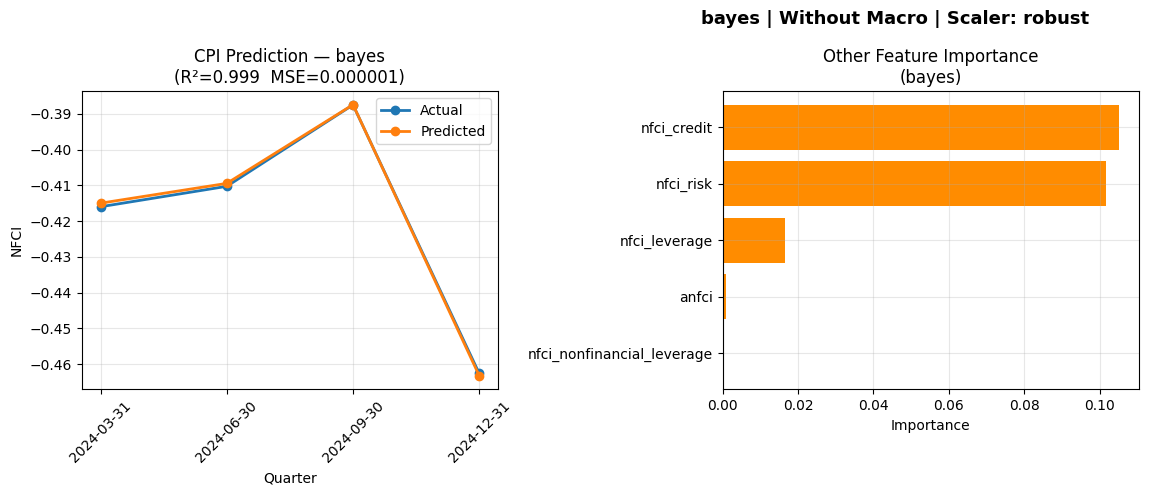

In [4]:

# Usage
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=False,
    model='bayes',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.418133     0.002135
2024-06-30         -0.410287    -0.410283     0.000004
2024-09-30         -0.387505    -0.384688     0.002817
2024-12-31         -0.462625    -0.463253     0.000628
-------------------------------------------------------
                                    MSE:     0.000003
                                     R²:       0.9957


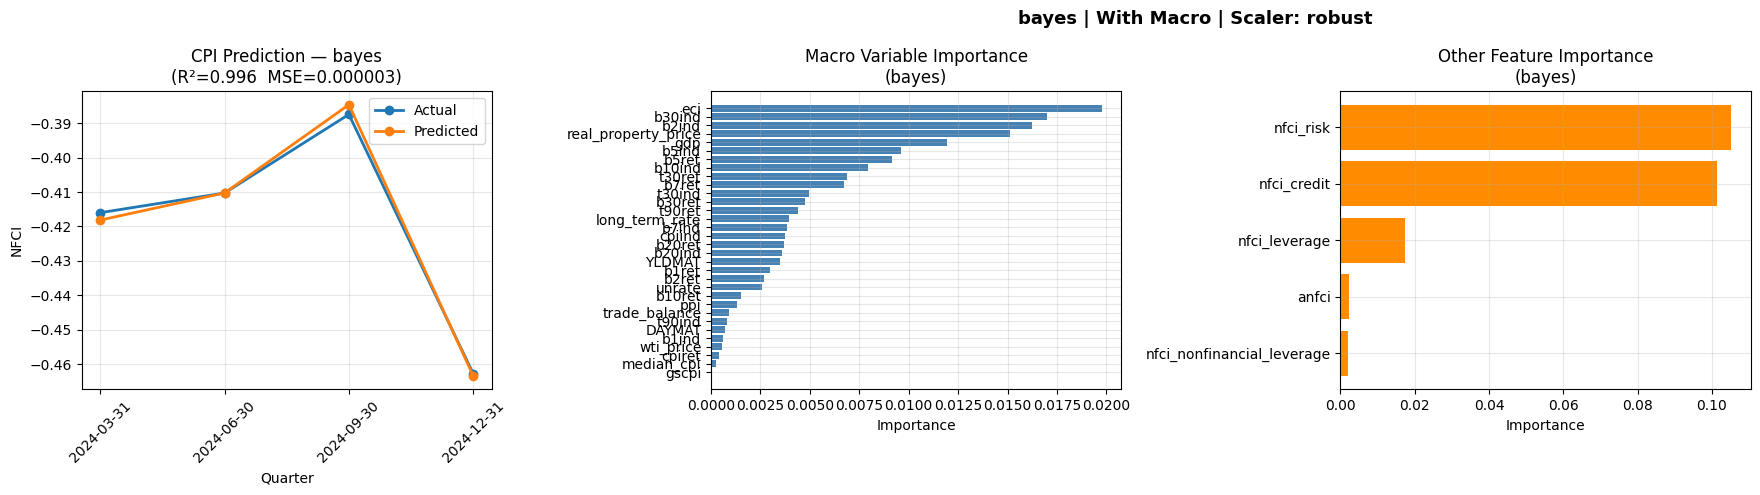

In [5]:

# Usage
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### Random Forest


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.456073     0.040075
2024-06-30         -0.410287    -0.449615     0.039328
2024-09-30         -0.387505    -0.447345     0.059840
2024-12-31         -0.462625    -0.505298     0.042673
-------------------------------------------------------
                                    MSE:     0.002139
                                     R²:      -1.8707


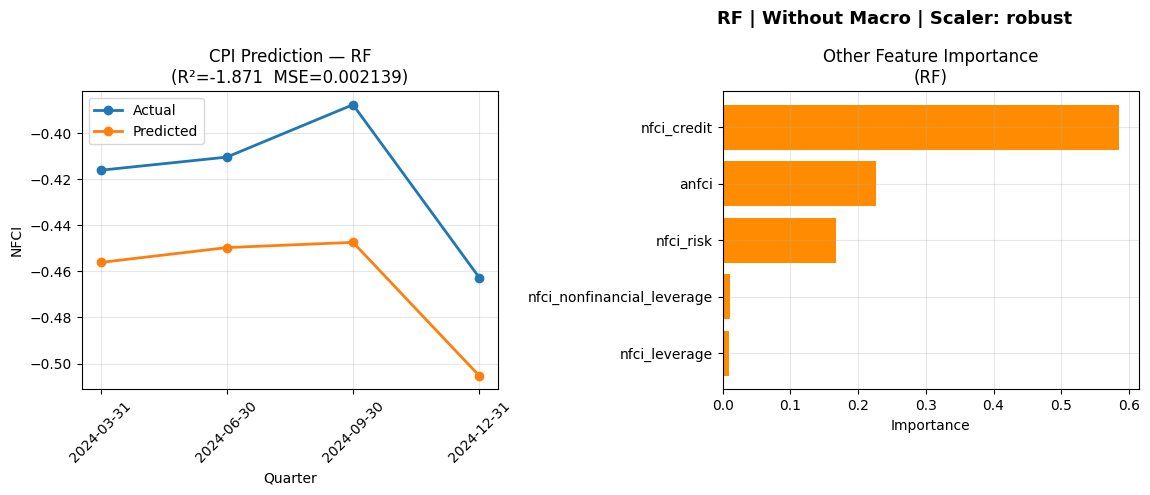

In [6]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=False,
    model='RF',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.480249     0.064251
2024-06-30         -0.410287    -0.475704     0.065417
2024-09-30         -0.387505    -0.473168     0.085663
2024-12-31         -0.462625    -0.526585     0.063960
-------------------------------------------------------
                                    MSE:     0.004959
                                     R²:      -5.6567


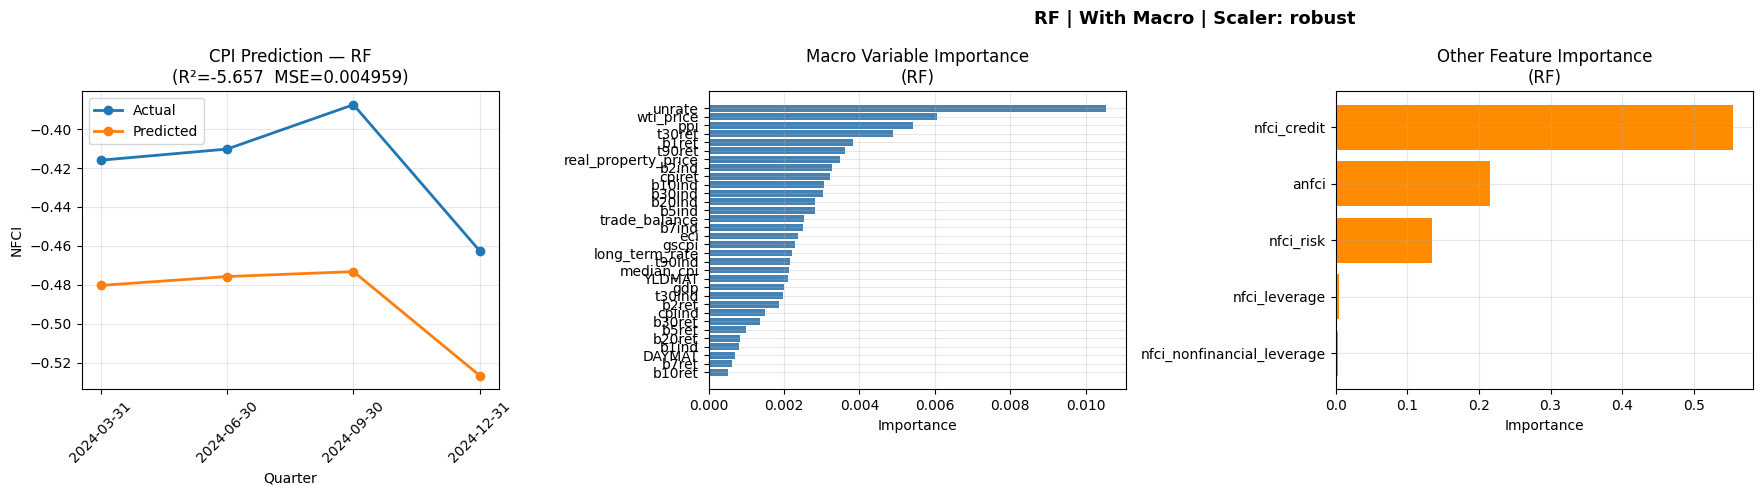

In [7]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=True,
    model='RF',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### XGB


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.458194     0.042197
2024-06-30         -0.410287    -0.457903     0.047616
2024-09-30         -0.387505    -0.454301     0.066796
2024-12-31         -0.462625    -0.512175     0.049550
-------------------------------------------------------
                                    MSE:     0.002741
                                     R²:      -2.6795


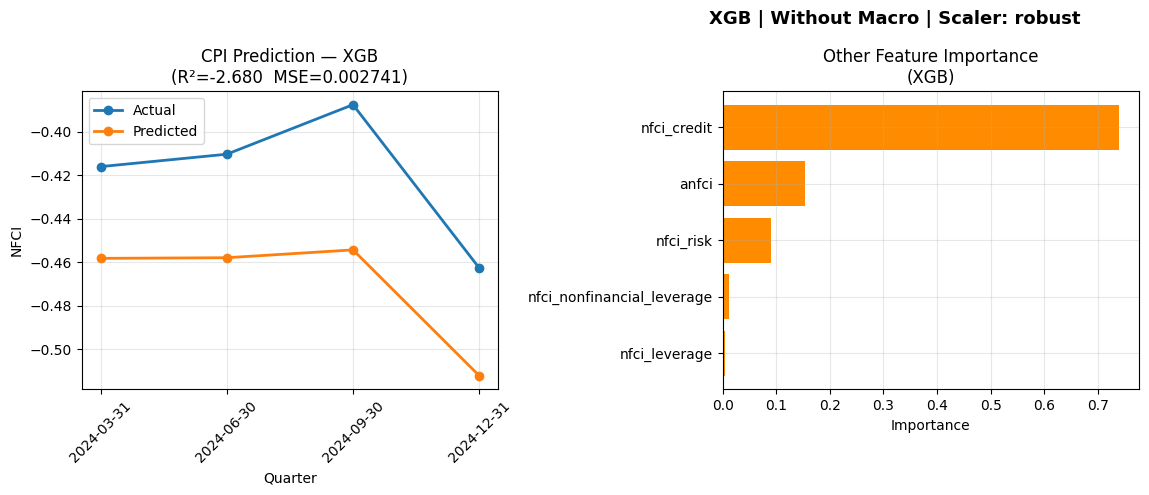

In [8]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=False,
    model='XGB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.480600     0.064602
2024-06-30         -0.410287    -0.476510     0.066223
2024-09-30         -0.387505    -0.452585     0.065080
2024-12-31         -0.462625    -0.536608     0.073983
-------------------------------------------------------
                                    MSE:     0.004567
                                     R²:      -5.1302


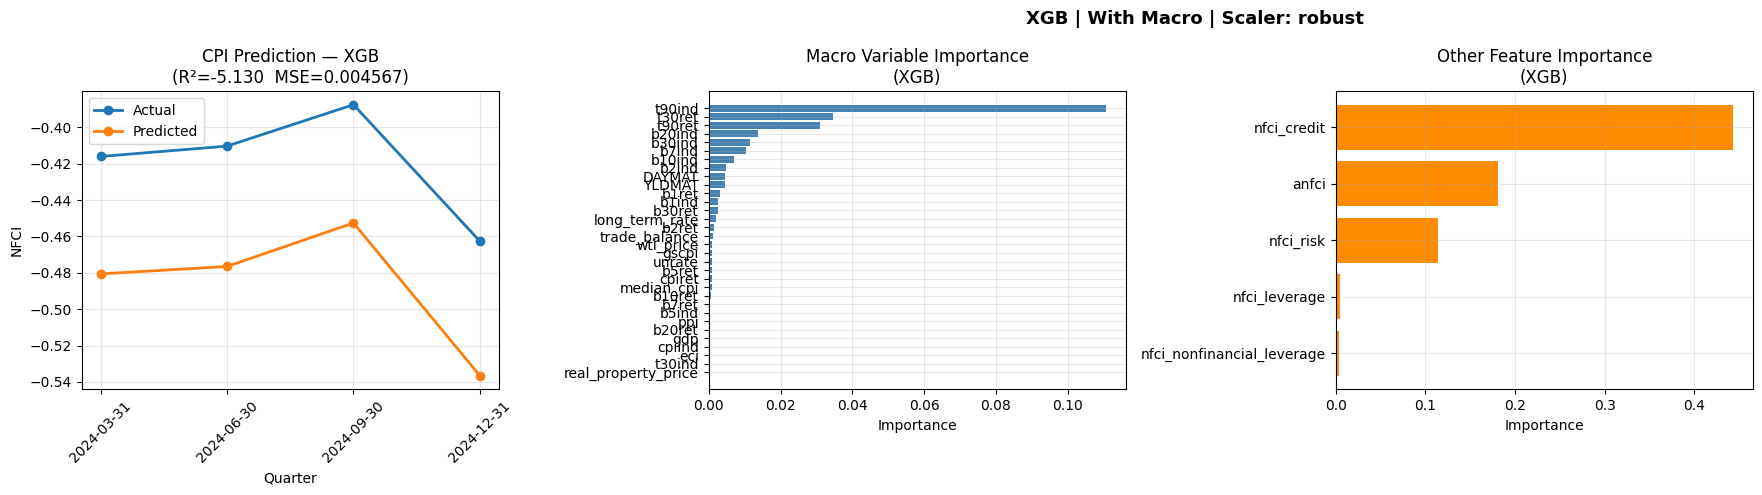

In [9]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### KNN


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.452524     0.036527
2024-06-30         -0.410287    -0.439865     0.029578
2024-09-30         -0.387505    -0.394605     0.007100
2024-12-31         -0.462625    -0.494937     0.032312
-------------------------------------------------------
                                    MSE:     0.000826
                                     R²:      -0.1086


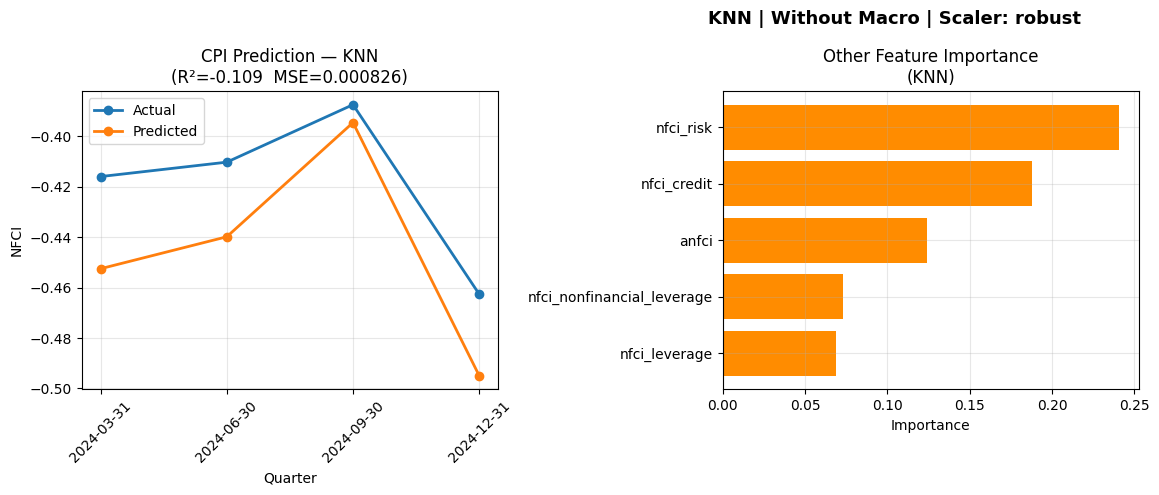

In [10]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=False,
    model='KNN',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.280303     0.135695
2024-06-30         -0.410287    -0.252794     0.157493
2024-09-30         -0.387505    -0.321203     0.066302
2024-12-31         -0.462625    -0.230274     0.232351
-------------------------------------------------------
                                    MSE:     0.025400
                                     R²:     -33.0946


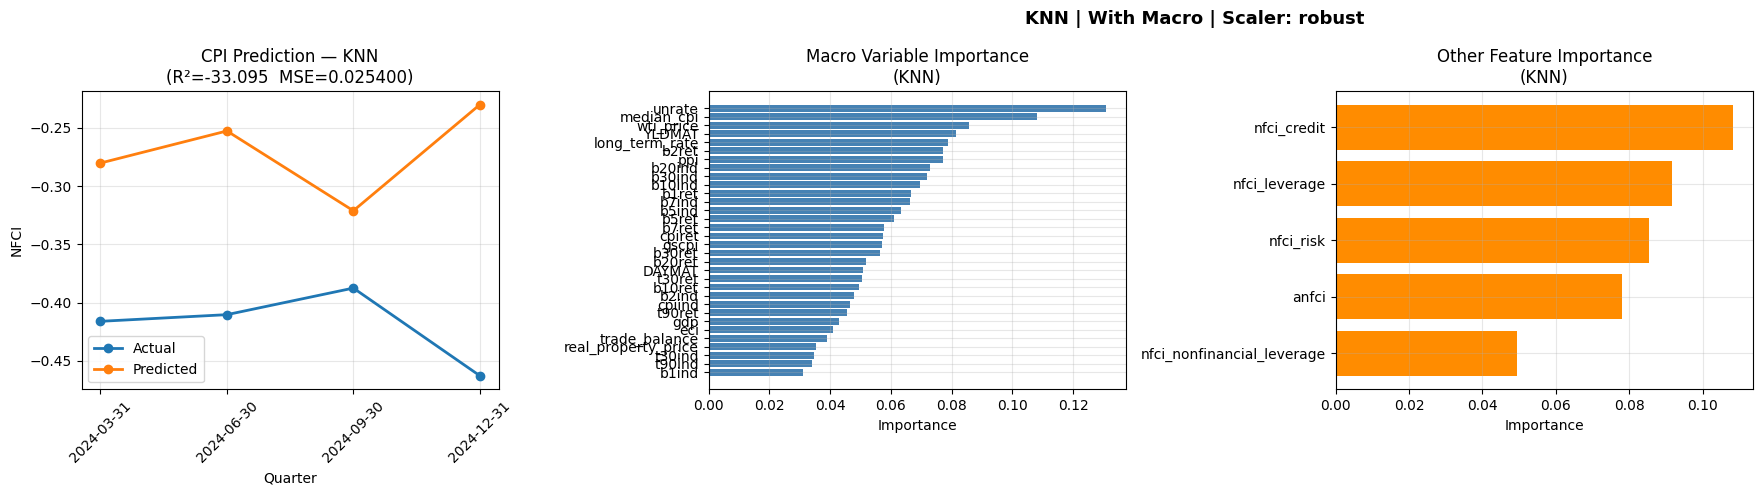

In [11]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=True,
    model='KNN',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### SVR


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.420632     0.004634
2024-06-30         -0.410287    -0.410017     0.000270
2024-09-30         -0.387505    -0.393823     0.006318
2024-12-31         -0.462625    -0.460997     0.001628
-------------------------------------------------------
                                    MSE:     0.000016
                                     R²:       0.9785


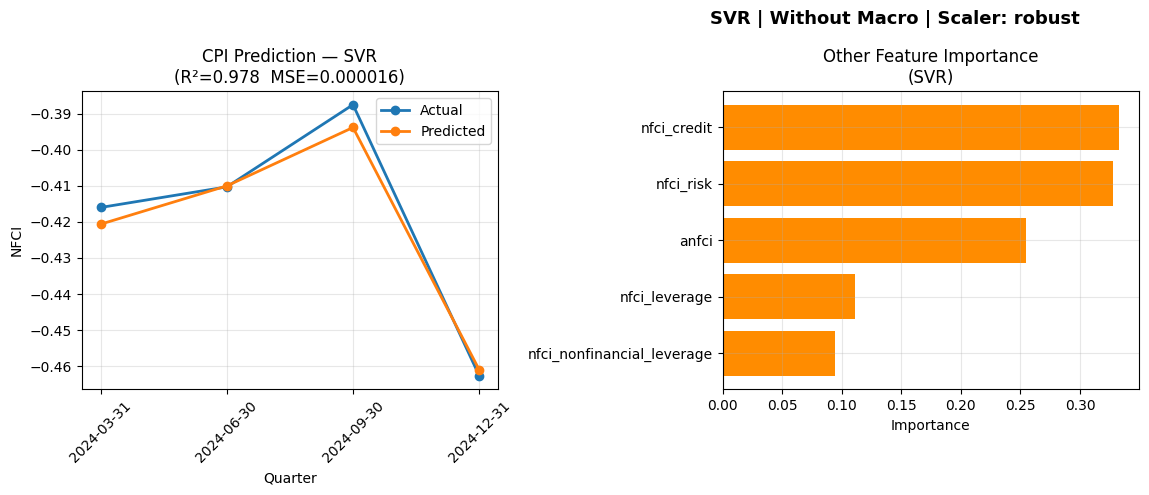

In [12]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=False,
    model='SVR',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.349803     0.066195
2024-06-30         -0.410287    -0.338704     0.071583
2024-09-30         -0.387505    -0.392198     0.004693
2024-12-31         -0.462625    -0.357227     0.105398
-------------------------------------------------------
                                    MSE:     0.005159
                                     R²:      -5.9252


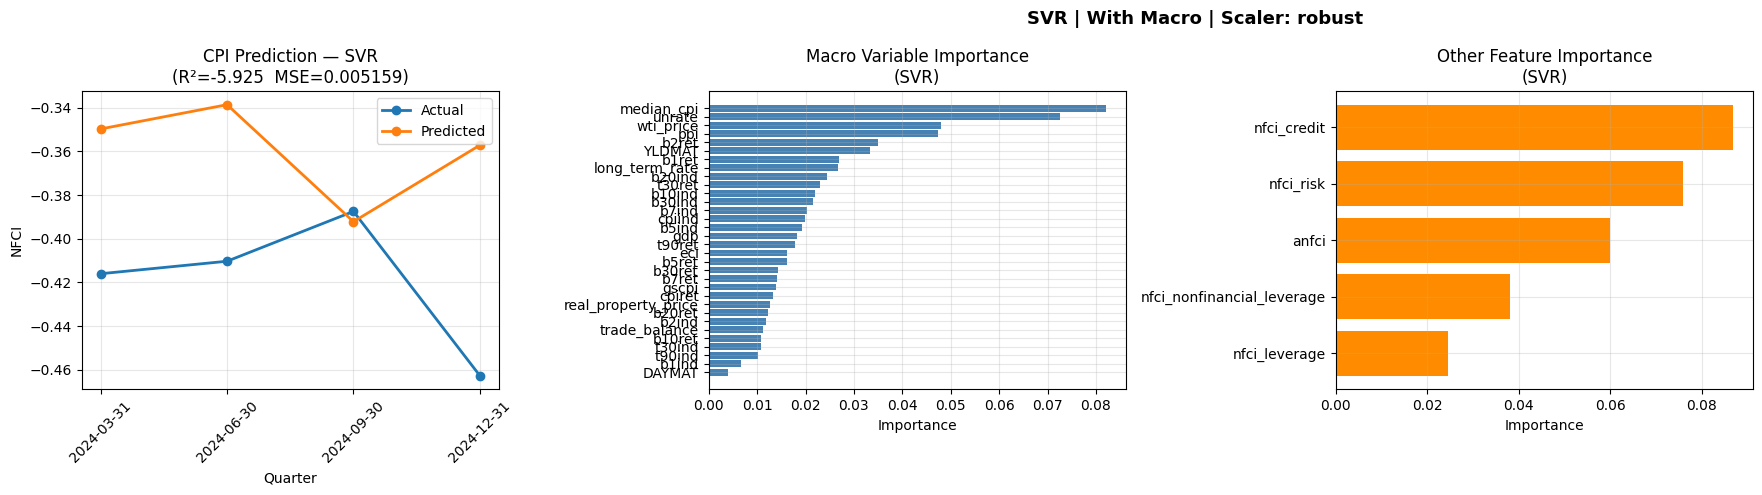

In [13]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=True,
    model='SVR',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### Catboost


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.428642     0.012644
2024-06-30         -0.410287    -0.411978     0.001690
2024-09-30         -0.387505    -0.406396     0.018891
2024-12-31         -0.462625    -0.482808     0.020183
-------------------------------------------------------
                                    MSE:     0.000232
                                     R²:       0.6889


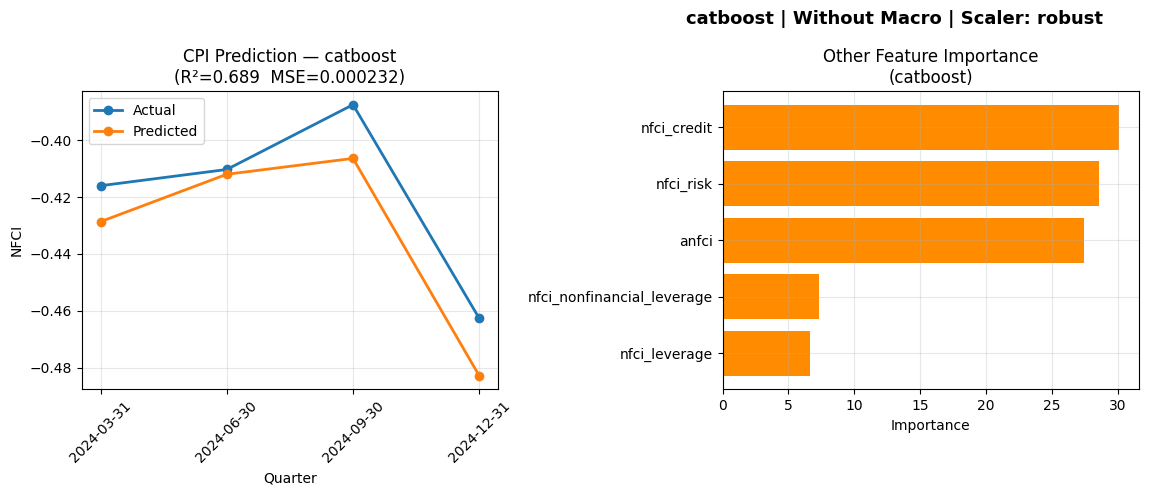

In [14]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=False,
    model='catboost',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31         -0.415998    -0.385902     0.030096
2024-06-30         -0.410287    -0.382001     0.028286
2024-09-30         -0.387505    -0.386851     0.000654
2024-12-31         -0.462625    -0.442168     0.020457
-------------------------------------------------------
                                    MSE:     0.000531
                                     R²:       0.2870


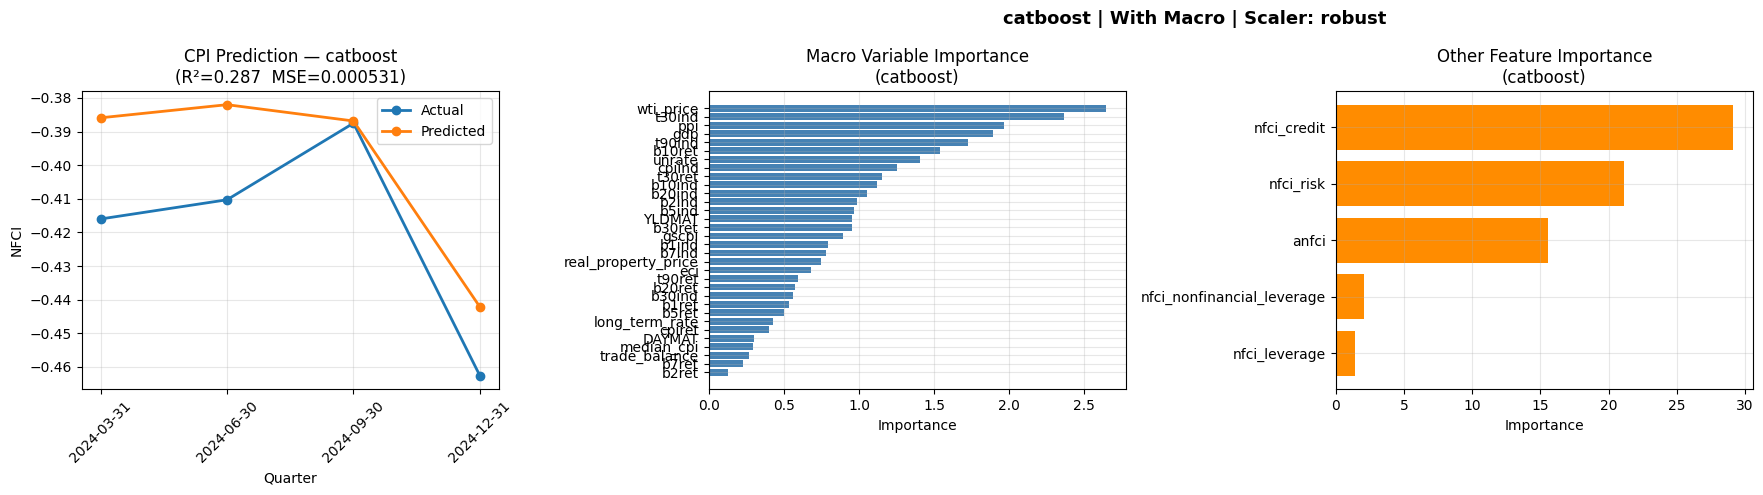

In [15]:
results, mse, r2 = rf_NFCI_prediction(
    df,
    use_macro=True,
    model='catboost',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)